Union,Intersection,Complement

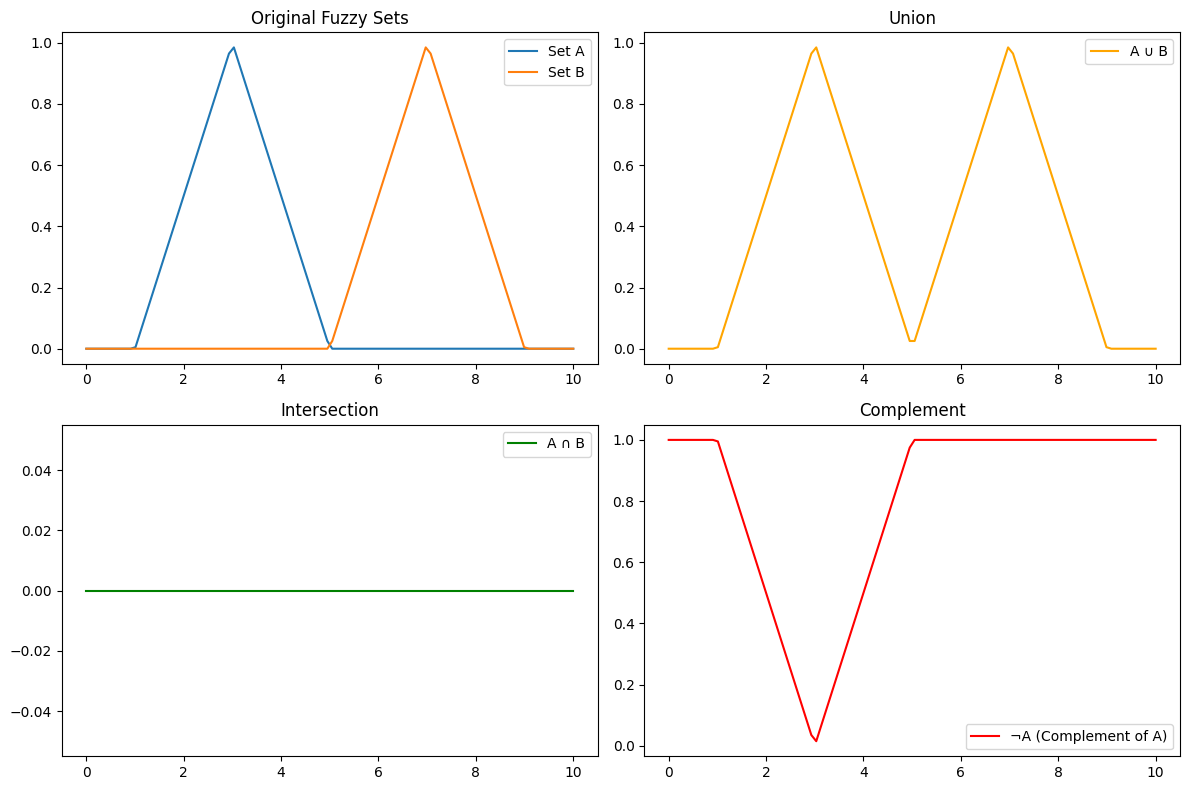

In [1]:


import numpy as np
import matplotlib.pyplot as plt

# Universe
x = np.linspace(0, 10, 100)

# Define two fuzzy sets A and B
A = np.maximum(0, 1 - abs(x - 3)/2)   # Triangular peak at 3
B = np.maximum(0, 1 - abs(x - 7)/2)   # Triangular peak at 7

# Fuzzy Set Operations
union = np.maximum(A, B)
intersection = np.minimum(A, B)
complement_A = 1 - A

# Plot
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(x, A, label="Set A")
plt.plot(x, B, label="Set B")
plt.title("Original Fuzzy Sets")
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(x, union, color='orange', label="A ∪ B")
plt.title("Union")
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(x, intersection, color='green', label="A ∩ B")
plt.title("Intersection")
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(x, complement_A, color='red', label="¬A (Complement of A)")
plt.title("Complement")
plt.legend()

plt.tight_layout()
plt.show()


# FUZZY membership functions

triangular function

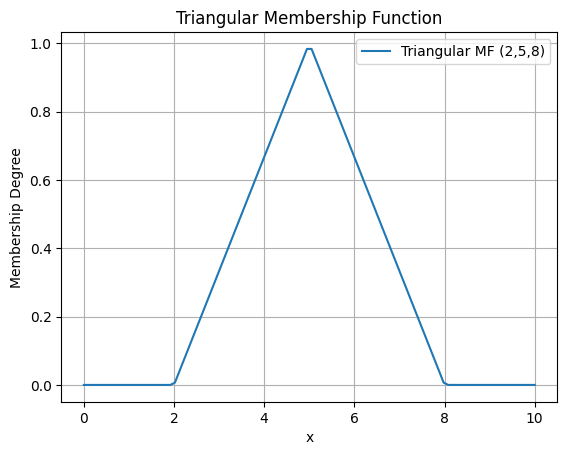

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def triangular(x, a, b, c):
    left = (x - a) / (b - a) if b != a else 0
    right = (c - x) / (c - b) if c != b else 0
    return np.maximum(np.minimum(left, right), 0)

x = np.linspace(0, 10, 100)
y = triangular(x, 2, 5, 8)

plt.plot(x, y, label="Triangular MF (2,5,8)")
plt.title("Triangular Membership Function")
plt.xlabel("x")
plt.ylabel("Membership Degree")
plt.grid(True)
plt.legend()
plt.show()


Trapezoidal function

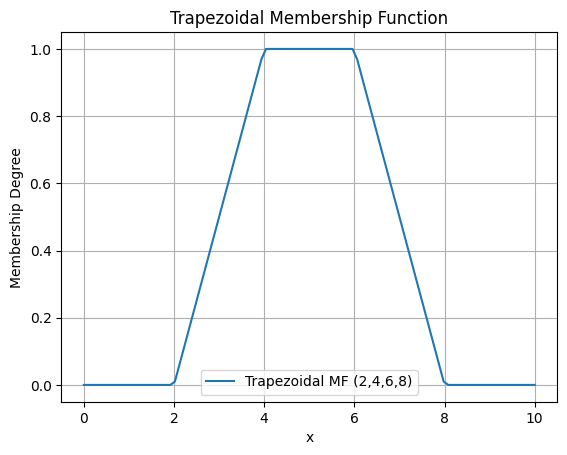

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def trapezoidal(x, a, b, c, d):
    y1 = (x - a) / (b - a) if b != a else 0
    y2 = 1
    y3 = (d - x) / (d - c) if d != c else 0
    return np.maximum(np.minimum(np.minimum(y1, y2), y3), 0)

x = np.linspace(0, 10, 100)
y = trapezoidal(x, 2, 4, 6, 8)

plt.plot(x, y, label="Trapezoidal MF (2,4,6,8)")
plt.title("Trapezoidal Membership Function")
plt.xlabel("x")
plt.ylabel("Membership Degree")
plt.grid(True)
plt.legend()
plt.show()


Gussian function

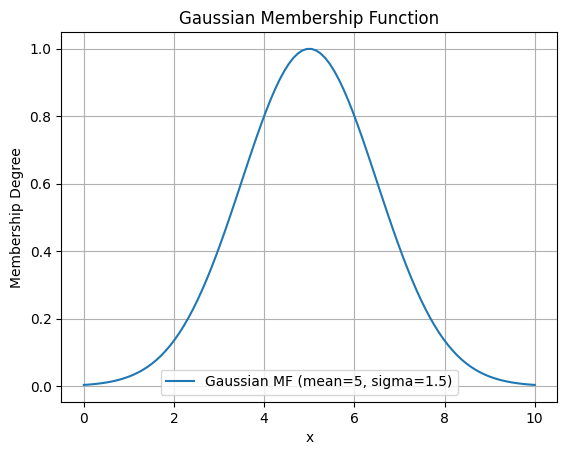

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def gaussian(x, mean, sigma):
    return np.exp(-0.5 * ((x - mean)/sigma)**2)

x = np.linspace(0, 10, 100)
y = gaussian(x, mean=5, sigma=1.5)

plt.plot(x, y, label="Gaussian MF (mean=5, sigma=1.5)")
plt.title("Gaussian Membership Function")
plt.xlabel("x")
plt.ylabel("Membership Degree")
plt.grid(True)
plt.legend()
plt.show()


# Designing a fuzzy controller

In [6]:


import numpy as np
import matplotlib.pyplot as plt
# Membership functions
def triangular(x, a, b, c):
    left = (x - a) / (b - a) if b != a else 0
    right = (c - x) / (c - b) if c != b else 0
    return np.maximum(np.minimum(left, right), 0)

# Universe
x = np.linspace(0, 10, 100)
# Fuzzify dirtiness
def fuzzify_dirtiness(value):
    low = triangular(value, 0, 0, 5)
    medium = triangular(value, 2.5, 5, 7.5)
    high = triangular(value, 5, 10, 10)
    return {'low': low, 'medium': medium, 'high': high}
# Fuzzify load
def fuzzify_load(value):
    light = triangular(value, 0, 0, 5)
    normal = triangular(value, 2.5, 5, 7.5)
    heavy = triangular(value, 5, 10, 10)
    return {'light': light, 'normal': normal, 'heavy': heavy}
# Rule base and inference
def fuzzy_inference(dirtiness, load):
    dirt_fuzzy = fuzzify_dirtiness(dirtiness)
    load_fuzzy = fuzzify_load(load)
    # Rules (min of antecedents)
    rules = {
        'short': min(dirt_fuzzy['low'], load_fuzzy['light']),
        'medium': max(
            min(dirt_fuzzy['medium'], load_fuzzy['normal']),
            min(dirt_fuzzy['low'], load_fuzzy['heavy']),
            min(dirt_fuzzy['high'], load_fuzzy['light'])
        ),
        'long': max(dirt_fuzzy['high'], load_fuzzy['heavy']),
    }
    return rules
# Defuzzify (center of gravity over discretized output)
def defuzzify(rules):
    time_range = np.linspace(0, 60, 600)
    short = np.array([triangular(t, 0, 15, 30) for t in time_range]) * rules['short']
    medium = np.array([triangular(t, 20, 35, 50) for t in time_range]) * rules['medium']
    long = np.array([triangular(t, 40, 55, 60) for t in time_range]) * rules['long']
    aggregated = np.maximum.reduce([short, medium, long])
    return np.sum(time_range * aggregated) / np.sum(aggregated)
# Final fuzzy controller
def washing_machine_controller(dirtiness, load):
    rules = fuzzy_inference(dirtiness, load)
    wash_time = defuzzify(rules)
    return wash_time
# Example
dirtiness = 6.5
load = 7.0
time = washing_machine_controller(dirtiness, load)
print(f"Dirtiness: {dirtiness}, Load: {load} → Wash Time: {time:.2f} minutes")


Dirtiness: 6.5, Load: 7.0 → Wash Time: 35.00 minutes
